<a href="https://colab.research.google.com/github/mcarden4-netizen/Homework-Intro-to-ML/blob/Homework/Homework1Part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

filetest = '/content/drive/My Drive/D3.csv'
data = pd.DataFrame(pd.read_csv(filetest))
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,X1,X2,X3,Y
0,0.000000,3.440000,0.440000,4.387545
1,0.040404,0.134949,0.888485,2.679650
2,0.080808,0.829899,1.336970,2.968490
3,0.121212,1.524848,1.785455,3.254065
4,0.161616,2.219798,2.233939,3.536375


In [86]:
x1 = data.values[:,0]
x2 = data.values[:,1]
x3 = data.values[:,2]
Y = data.values[:,3]

a = len(Y)

In [87]:
X = np.column_stack((np.ones(len(Y)), x1, x2, x3))

X[:5]

array([[1.        , 0.        , 3.44      , 0.44      ],
       [1.        , 0.04040404, 0.1349495 , 0.88848485],
       [1.        , 0.08080808, 0.82989899, 1.3369697 ],
       [1.        , 0.12121212, 1.52484848, 1.78545454],
       [1.        , 0.16161616, 2.21979798, 2.23393939]])

In [88]:
X_1= X.reshape(-1,1)

X_1[:10]

array([[1.        ],
       [0.        ],
       [3.44      ],
       [0.44      ],
       [1.        ],
       [0.04040404],
       [0.1349495 ],
       [0.88848485],
       [1.        ],
       [0.08080808]])

In [89]:
def determine_data(input_data, output_data, theta):

  Predictions = input_data.dot(theta)
  Errors = np.subtract(Predictions, output_data)
  Squared_Errors = np.square(Errors)
  C = 1/(2*a) * np.sum(Squared_Errors)

  return C

In [90]:
def gradient_descent(input_data , output_data, theta, alpha, instances):

  b = len(x1)

  data_history = np.zeros(instances)

  for i in range(instances):

    Predictions = input_data.dot(theta)
    Errors = np.subtract(Predictions, output_data)
    Gradient = (alpha/b) * (input_data.T.dot(Errors))
    theta = theta - Gradient
    data_history[i] = determine_data(input_data, output_data, theta)


  return theta, data_history

In [91]:
theta = [0.,0.,0.,0.]
instances = 1000
alpha = .1
alpha2 = .07
alpha3 = .05
alpha4 = .03
alpha5 = .01

In [92]:
theta1, data_history1 = gradient_descent(X, Y, theta, alpha, instances)
theta1_2, data_history1_2 = gradient_descent(X, Y, theta, alpha2, instances)
theta1_3, data_history1_3 = gradient_descent(X, Y, theta, alpha3, instances)
theta1_4, data_history1_4 = gradient_descent(X, Y, theta, alpha4, instances)
theta1_5, data_history1_5 = gradient_descent(X, Y, theta, alpha5, instances)

In [93]:
print("Model using X:")
print("Y =", theta1[0], "+", theta1[1], 'x1', "+", theta1[2], 'x2', "+", theta1[3], 'x3')
print('\n')
print("Final Losses:")
print("X:", data_history1[-1])

Model using X:
Y = 5.313935769531634 + -2.0036865792753904 x1 + 0.5326015740310899 x2 + -0.2655679465553415 x3


Final Losses:
X: 0.7384642444206544


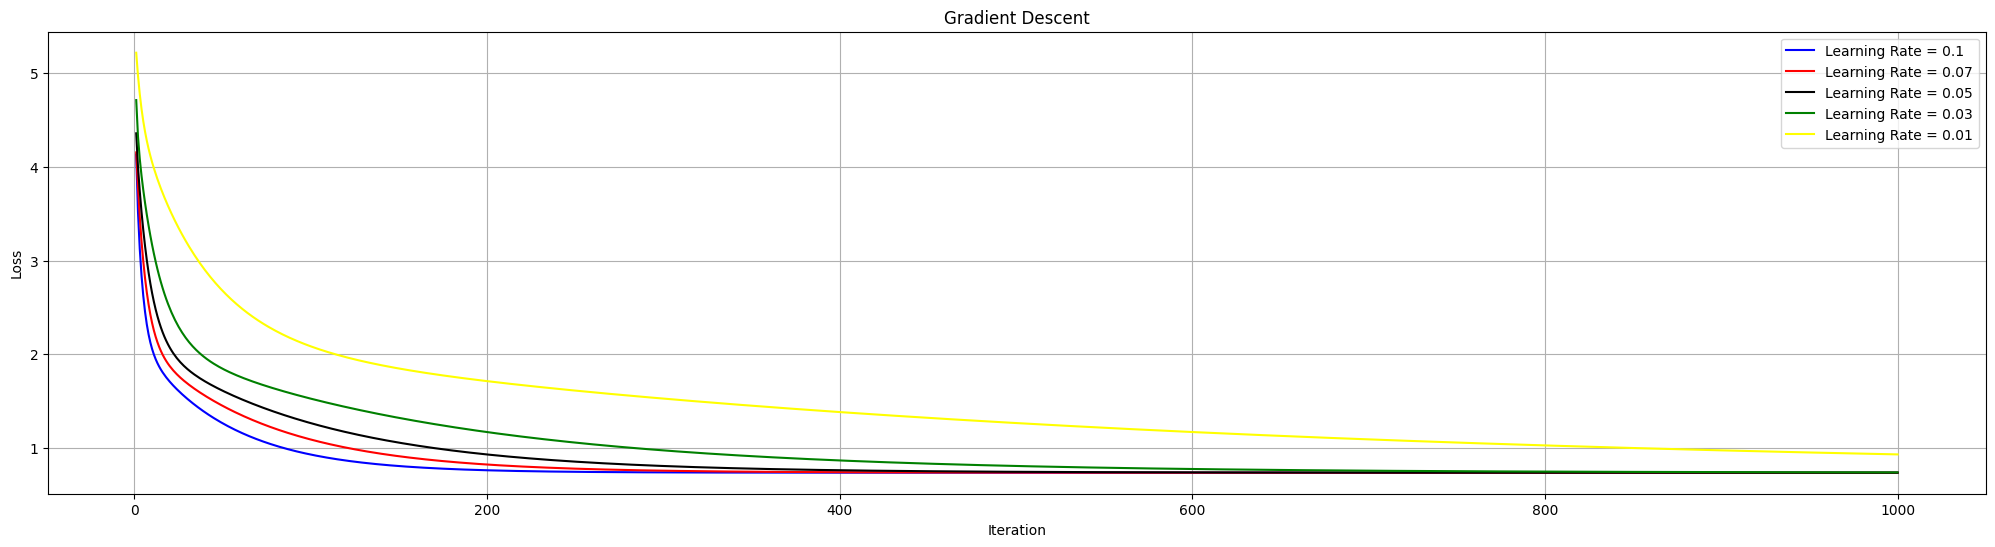

In [94]:
plt.figure(figsize=(25,6))

plt.plot(range(1, instances + 1), data_history1, color='blue')
plt.plot(range(1, instances + 1), data_history1_2, color='red')
plt.plot(range(1, instances + 1), data_history1_3, color='black')
plt.plot(range(1, instances + 1), data_history1_4, color='green')
plt.plot(range(1, instances + 1), data_history1_5, color='yellow')
plt.grid(True)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Gradient Descent')
plt.legend(['Learning Rate = 0.1', 'Learning Rate = 0.07', 'Learning Rate = 0.05', 'Learning Rate = 0.03', 'Learning Rate = 0.01'])

In [95]:
new_X = np.array([
    [1, 1, 1, 1],
    [1, 2, 0, 4],
    [1, 3, 2, 1]
])

predictions = new_X.dot(theta)

print("\nPredictions:")

print("For (X1, X2, X3) = (1, 1, 1):", predictions[0])
print("For (X1, X2, X3) = (2, 0, 4):", predictions[1])
print("For (X1, X2, X3) = (3, 2, 1):", predictions[2])


Predictions:
For (X1, X2, X3) = (1, 1, 1): 0.0
For (X1, X2, X3) = (2, 0, 4): 0.0
For (X1, X2, X3) = (3, 2, 1): 0.0
